In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Test des frontières efficientes avec des valeurs arbitraires (3 actifs)

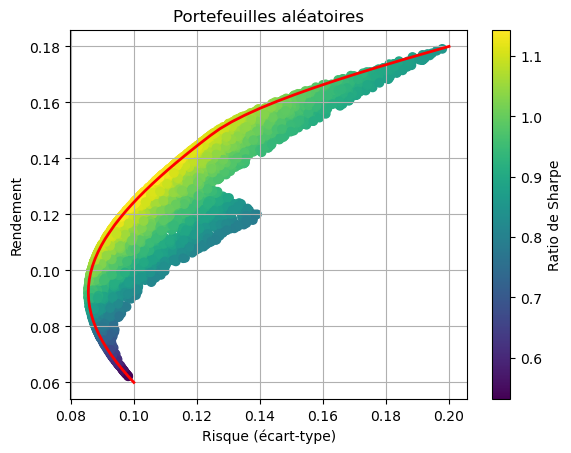

In [2]:
# Rendements et covariances des actifs
R = np.array([0.06, 0.12, 0.18])
V = np.array([[0.01, 0.005, 0], [0.005, 0.02, 0.002], [0, 0.002, 0.04]])

# Générer des portefeuilles aléatoires
n_portfolios = 5000
weights = np.random.dirichlet(np.ones(len(R)), size=n_portfolios)
returns = np.dot(weights, R)
risks = np.sqrt(np.diag(np.dot(np.dot(weights, V), weights.T)))

# Tracer les portefeuilles aléatoires
plt.scatter(risks, returns, c=(returns - 0.01) / risks, marker='o')
plt.grid(True)
plt.xlabel('Risque (écart-type)')
plt.ylabel('Rendement')
plt.colorbar(label='Ratio de Sharpe')
plt.title('Portefeuilles aléatoires')

# Calculer la frontière efficiente
from scipy.optimize import minimize

def portfolio_variance(weights):
    return np.dot(np.dot(weights, V), weights.T)

def portfolio_return(weights):
    return np.dot(weights, R)

def efficient_frontier(R_target):
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                   {'type': 'eq', 'fun': lambda w: portfolio_return(w) - R_target})
    bounds = tuple((0, 1) for _ in range(len(R)))
    result = minimize(portfolio_variance, len(R) * [1 / len(R)], bounds=bounds, constraints=constraints)
    return result.x

R_targets = np.linspace(min(R), max(R), 50)
efficient_weights = np.array([efficient_frontier(R_target) for R_target in R_targets])
efficient_returns = np.dot(efficient_weights, R)
efficient_risks = np.sqrt(np.diag(np.dot(np.dot(efficient_weights, V), efficient_weights.T)))

# Tracer la frontière efficiente
plt.plot(efficient_risks, efficient_returns, 'r-', linewidth=2)
plt.show()

Test CML frontière efficiente

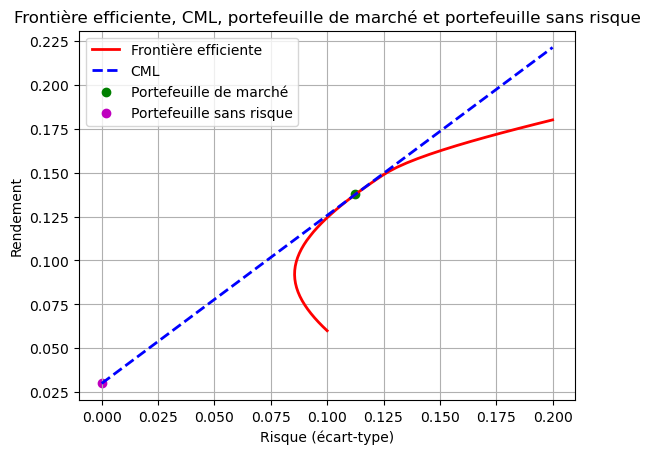

In [37]:
# Rendements et covariances des actifs
R = np.array([0.06, 0.12, 0.18])
V = np.array([[0.01, 0.005, 0], [0.005, 0.02, 0.002], [0, 0.002, 0.04]])

# Rendement sans risque
R_f = 0.03

# Fonctions pour calculer le rendement et la variance du portefeuille
def portfolio_return(weights):
    return np.dot(weights, R)

def portfolio_variance(weights):
    return np.dot(np.dot(weights, V), weights.T)

# Trouver le portefeuille de marché (portefeuille tangent)
from scipy.optimize import minimize

def neg_sharpe_ratio(weights):
    return -(portfolio_return(weights) - R_f) / np.sqrt(portfolio_variance(weights))

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(len(R)))
initial_guess = len(R) * [1 / len(R)]

result = minimize(neg_sharpe_ratio, initial_guess, bounds=bounds, constraints=constraints)
market_portfolio_weights = result.x
market_portfolio_return = portfolio_return(market_portfolio_weights)
market_portfolio_risk = np.sqrt(portfolio_variance(market_portfolio_weights))

# Tracer la frontière efficiente et la CML
R_targets = np.linspace(min(R), max(R), 50)
efficient_weights = np.array([efficient_frontier(R_target) for R_target in R_targets])
efficient_returns = np.dot(efficient_weights, R)
efficient_risks = np.sqrt(np.diag(np.dot(np.dot(efficient_weights, V), efficient_weights.T)))

plt.plot(efficient_risks, efficient_returns, 'r-', linewidth=2, label='Frontière efficiente')

CML_risks = np.linspace(0, max(efficient_risks), 50)
CML_returns = R_f + (market_portfolio_return - R_f) / market_portfolio_risk * CML_risks
plt.plot(CML_risks, CML_returns, 'b--', linewidth=2, label='CML')

plt.scatter(market_portfolio_risk, market_portfolio_return, c='g', marker='o', label='Portefeuille de marché')
plt.scatter(0, R_f, c='m', marker='o', label='Portefeuille sans risque')

plt.xlabel('Risque (écart-type)')
plt.ylabel('Rendement')
plt.legend(loc='best')
plt.title('Frontière efficiente, CML, portefeuille de marché et portefeuille sans risque')
plt.grid(True)
plt.show()


Récupération des données prix crypto sur CoinGecko

In [3]:
import requests
from datetime import datetime

In [ ]:
import requests

def get_top_cryptos(limit=13):
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        "vs_currency": "usd",
        "order": "market_cap_desc",
        "per_page": 100, # Récupérer les 100 premières cryptos pour être sûr d'en avoir 15 après filtrage
        "page": 1,
        "sparkline": False,
        "price_change_percentage": "1h,24h,7d,14d,30d,200d,1y"
    }
    response = requests.get(url, params=params)
    data = response.json()

    top_cryptos = []
    excluded_names = ['Tether', 'USD Coin', 'Lido Staked Ether', 'Binance USD','Wrapped Bitcoin','Dai']

    for crypto in data:
        if crypto["name"] not in excluded_names:
            top_cryptos.append(crypto)
            if len(top_cryptos) >= limit:
                break

    return top_cryptos

top_15_cryptos = get_top_cryptos()

In [5]:
def get_daily_prices(crypto_id, start_date, end_date):
    start_timestamp = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp())
    end_timestamp = int(datetime.strptime(end_date, "%Y-%m-%d").timestamp())
    url = f"https://api.coingecko.com/api/v3/coins/{crypto_id}/market_chart"
    params = {
        "vs_currency": "usd",
        "days": "max",
        "interval": "daily"
    }
    response = requests.get(url, params=params)
    data = response.json()

    if "prices" not in data:
        print(f"Error: Unexpected API response for {crypto_id}")
        return pd.Series(dtype=float)

    prices = [{"time": datetime.fromtimestamp(x[0] / 1000), "close": x[1]} for x in data["prices"]]
    df = pd.DataFrame(prices)

    if "time" not in df.columns:
        print(f"Error: 'time' column not found in DataFrame for {crypto_id}")
        return pd.Series(dtype=float)

    df.set_index("time", inplace=True)
    df = df.loc[start_date:end_date]

    return df["close"]




In [6]:
start_date = "2017-01-01"
end_date = datetime.now().strftime('%Y-%m-%d')

top_cryptos = get_top_cryptos()
crypto_prices = pd.DataFrame()

for crypto in top_cryptos:
    crypto_id = crypto["id"]
    crypto_symbol = crypto["symbol"].upper()
    crypto_name = crypto["name"]

    prices = get_daily_prices(crypto_id, start_date, end_date)
    crypto_prices[crypto_symbol] = prices

crypto_prices.dropna(inplace=True)

crypto_returns = crypto_prices.pct_change().dropna()

In [8]:
crypto_returns.mean()

BTC      0.001772
ETH      0.002949
BNB      0.004309
XRP      0.002706
ADA      0.003207
DOGE     0.008841
MATIC    0.007094
SOL      0.005002
DOT      0.002261
LTC      0.002157
TRX      0.002225
SHIB     0.060303
AVAX     0.004016
dtype: float64

In [9]:
crypto_prices

,BTC,ETH,BNB,XRP,ADA,DOGE,MATIC,SOL,DOT,LTC,TRX,SHIB,AVAX
time,,,,,,,,,,,,,
2020-09-22 02:00:00,10439.522489,341.277131,23.533250,0.231657,0.080367,0.002621,0.018930,2.773660,4.089750,43.243477,0.024937,1.231771e-10,5.284244
2020-09-23 02:00:00,10527.587847,343.917547,24.026976,0.233163,0.081443,0.002646,0.019625,2.940216,4.168356,44.487314,0.024989,1.182029e-10,5.284244
2020-09-24 02:00:00,10223.784106,321.077435,22.810300,0.220603,0.076628,0.002542,0.017737,2.835501,4.016036,42.971450,0.024789,1.066568e-10,3.491229
2020-09-25 02:00:00,10726.530083,348.821020,24.518301,0.232699,0.082607,0.002635,0.018975,3.130126,4.389749,44.910404,0.026079,1.173661e-10,4.573891
2020-09-26 02:00:00,10681.993848,351.331567,24.625905,0.241207,0.096791,0.002699,0.019104,3.191006,4.412863,45.910860,0.027111,1.184209e-10,4.702974
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-27 02:00:00,28352.191321,1867.589325,330.437216,0.461767,0.401301,0.078635,0.985312,21.256248,5.846075,88.103764,0.065209,1.019505e-05,17.166014
2023-04-28 02:00:00,29483.521705,1910.456779,331.514836,0.467124,0.410319,0.080258,1.013173,22.337864,5.974929,89.705820,0.065875,1.030938e-05,17.730408
2023-04-29 02:00:00,29339.994998,1894.428084,324.479902,0.480183,0.405229,0.080432,0.998712,23.374818,5.947740,89.707686,0.066751,1.029688e-05,17.562968


In [10]:
import scipy.stats as stats

# Calcul des statistiques descriptives pour chaque crypto-monnaie
stats_summary = pd.DataFrame(index=crypto_returns.columns)

stats_summary['Mean'] = crypto_returns.mean()
stats_summary['Median'] = crypto_returns.median()
stats_summary['Volatility'] = crypto_returns.std()
stats_summary['Skewness'] = crypto_returns.skew()
stats_summary['Kurtosis'] = crypto_returns.kurtosis()

print(stats_summary)


           Mean    Median  Volatility   Skewness    Kurtosis
BTC    0.001772  0.000472    0.036613   0.193871    3.330610
ETH    0.002949  0.002628    0.047309  -0.026462    3.530313
BNB    0.004309  0.001467    0.055998   2.807517   36.402299
XRP    0.002706  0.000721    0.063234   1.313566   14.432334
ADA    0.003207  0.000341    0.055372   0.760076    3.584323
DOGE   0.008841 -0.000898    0.139869  16.048378  370.295672
MATIC  0.007094  0.000420    0.078810   1.910001   10.020601
SOL    0.005002 -0.000483    0.075126   1.044812   10.098051
DOT    0.002261 -0.000677    0.061526   0.638066    6.149040
LTC    0.002157  0.001066    0.052496  -0.000801    5.793413
TRX    0.002225  0.001924    0.048540   0.762921   10.205459
SHIB   0.060303 -0.000787    1.154858  28.245397  835.661261
AVAX   0.004016  0.000078    0.076051   1.502921   13.142599


D'après les statistiques descriptives des rendements des crypto-monnaies, voici quelques interprétations :

Moyenne (Mean) : DOGE présente la moyenne de rendement la plus élevée parmi les crypto-monnaies, suivie de MATIC et SOL. Cela signifie que DOGE a généré des rendements quotidiens plus élevés en moyenne que les autres crypto-monnaies. Cependant, une moyenne élevée peut aussi être le résultat de quelques jours avec des rendements exceptionnellement élevés, donc il est important de considérer d'autres statistiques pour avoir une image complète.

Médiane (Median) : La médiane donne une meilleure idée de la performance "typique" d'une crypto-monnaie, car elle est moins sensible aux valeurs extrêmes. ETH et TRX ont les médianes les plus élevées, ce qui indique qu'elles ont eu des performances plus régulières.

Volatilité (Volatility) : La volatilité mesure la dispersion des rendements et est souvent utilisée comme indicateur de risque. DOGE a la volatilité la plus élevée parmi les crypto-monnaies, ce qui indique un niveau de risque plus élevé par rapport aux autres actifs. BUSD, en revanche, a la volatilité la plus faible, suggérant un niveau de risque plus faible.

Skewness (Asymétrie) : La skewness mesure l'asymétrie de la distribution des rendements. DOGE présente une skewness extrêmement élevée, ce qui indique que la distribution des rendements est fortement asymétrique avec une queue à droite (c'est-à-dire des rendements extrêmement élevés occasionnels). En revanche, LTC et ETH ont une skewness négative, ce qui suggère une distribution asymétrique avec une queue à gauche (c'est-à-dire des rendements extrêmement faibles occasionnels).

Kurtosis (Aplatissement) : La kurtosis mesure l'épaisseur des queues de la distribution des rendements. Une kurtosis élevée indique que la distribution a des queues plus épaisses et un pic plus pointu que la distribution normale, ce qui suggère un risque plus élevé d'événements extrêmes (gains ou pertes importants). DOGE a une kurtosis extrêmement élevée, indiquant un risque plus élevé d'événements extrêmes par rapport aux autres crypto-monnaies.

En résumé, DOGE présente les rendements moyens les plus élevés, mais aussi la volatilité, l'asymétrie et la kurtosis les plus élevées, ce qui suggère un niveau de risque plus élevé. BUSD a la volatilité la plus faible, indiquant un niveau de risque plus faible. ETH et TRX ont des médianes de rendement élevées, suggérant des performances plus régulières.

Cependant, il est important de noter que ces interprétations sont basées sur des données historiques et ne garantissent pas les performances futures.

Dogecoin (DOGE) est une crypto-monnaie qui a été initialement créée en 2013 comme une parodie des crypto-monnaies populaires de l'époque, en particulier Bitcoin. Elle est basée sur le mème Internet populaire "Doge", qui représente un Shiba Inu, une race de chien japonaise. Dogecoin a été conçu par les développeurs Billy Markus et Jackson Palmer pour être une monnaie numérique accessible et amusante, ainsi qu'un moyen de sensibilisation aux crypto-monnaies.

Dogecoin est basé sur la technologie blockchain, tout comme Bitcoin et d'autres crypto-monnaies. Sa blockchain est décentralisée, ce qui signifie qu'elle n'est contrôlée par aucune autorité centrale. Les transactions Dogecoin sont sécurisées par la preuve de travail (Proof of Work), un mécanisme de consensus utilisé par de nombreuses autres crypto-monnaies. Le protocole de Dogecoin est basé sur le protocole Luckycoin, qui est lui-même dérivé du protocole Litecoin.

Bien que Dogecoin ait été créé à l'origine comme une blague, il a rapidement gagné en popularité et est devenu une crypto-monnaie légitime avec une capitalisation boursière importante. Dogecoin a également été utilisé pour financer divers projets caritatifs et sociaux, ce qui a renforcé son image positive au sein de la communauté des crypto-monnaies.

Au fil des années, Dogecoin a bénéficié d'un soutien important de la part de personnalités influentes, notamment Elon Musk, le PDG de Tesla et SpaceX, qui a régulièrement tweeté et exprimé son intérêt pour la monnaie. Cela a contribué à augmenter la visibilité et la valeur de Dogecoin sur le marché des crypto-monnaies.

Le SHIB ayant des rendements beaucoup trop élevé aplati toutes les autres courbes

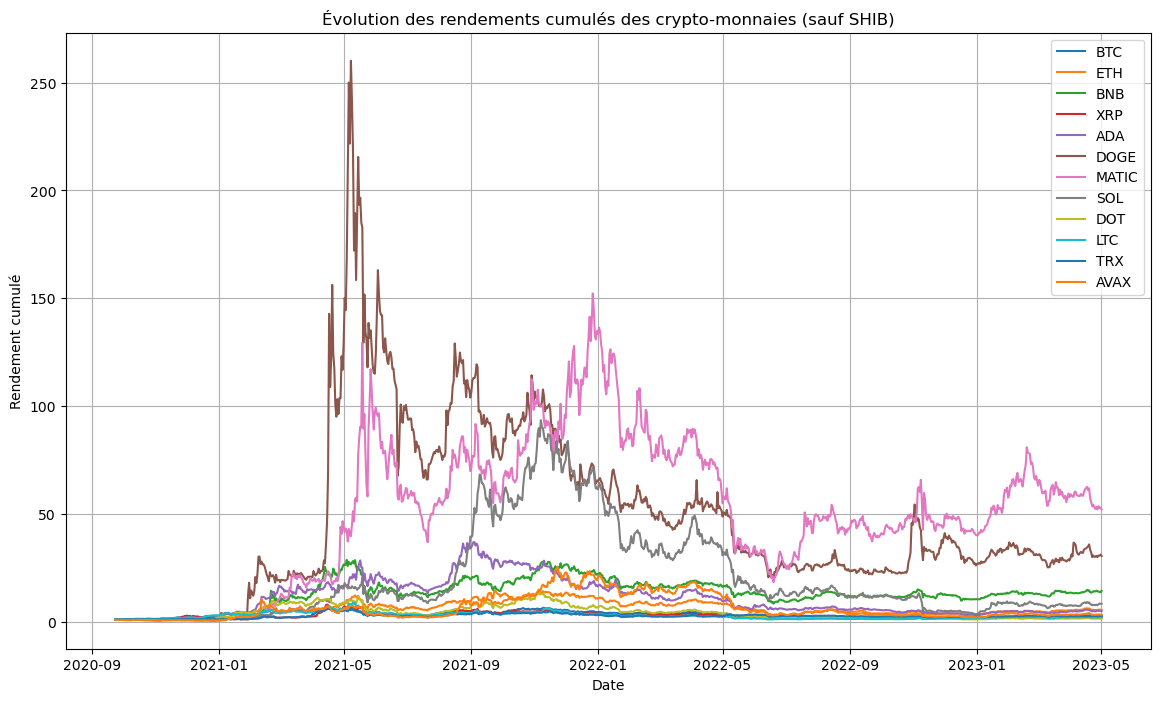

In [14]:
import matplotlib.pyplot as plt

# Calculer les rendements cumulés
cumulative_returns = (1 + crypto_returns).cumprod()

# Filtrer les colonnes sans le SHIB
cumulative_returns_filtered = cumulative_returns.loc[:, cumulative_returns.columns != "SHIB"]

# Créer un graphique
plt.figure(figsize=(14, 8))
for column in cumulative_returns_filtered.columns:
    plt.plot(cumulative_returns_filtered.index, cumulative_returns_filtered[column], label=column)

plt.xlabel("Date")
plt.ylabel("Rendement cumulé")
plt.title("Évolution des rendements cumulés des crypto-monnaies (sauf SHIB)")
plt.legend()
plt.grid()
plt.show()

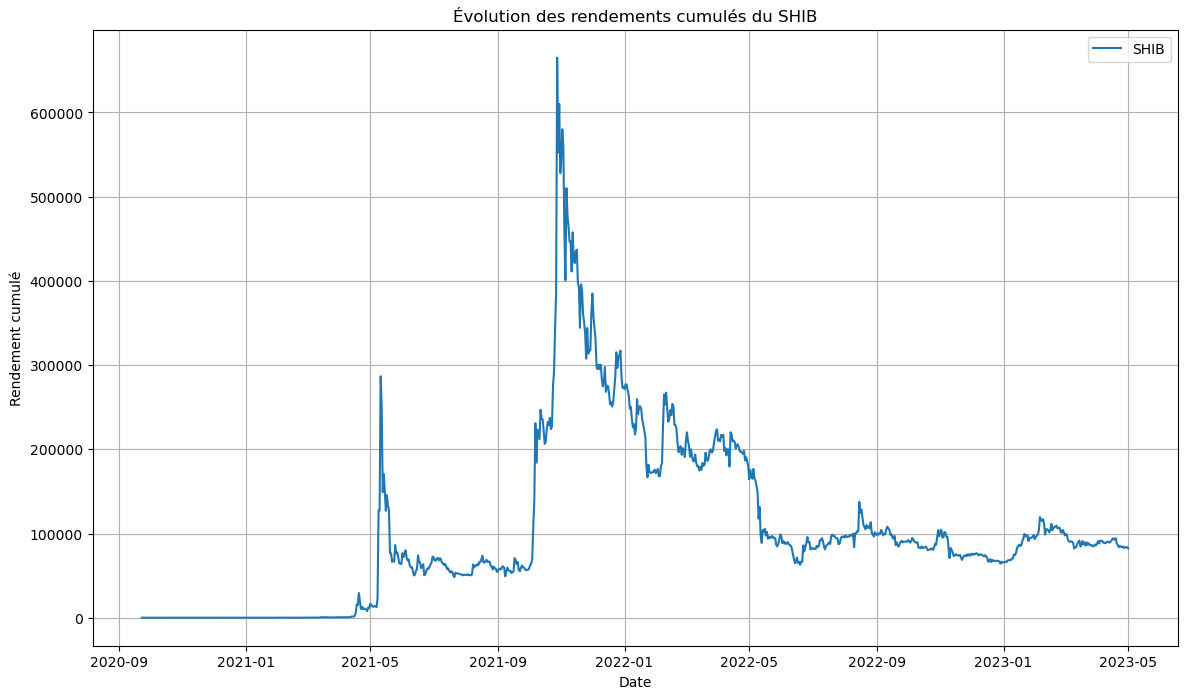

In [15]:
import matplotlib.pyplot as plt

# Calculer les rendements cumulés
cumulative_returns = (1 + crypto_returns).cumprod()

# Extraire la colonne du SHIB
shib_cumulative_returns = cumulative_returns["SHIB"]

# Créer un graphique
plt.figure(figsize=(14, 8))
plt.plot(shib_cumulative_returns.index, shib_cumulative_returns, label="SHIB")

plt.xlabel("Date")
plt.ylabel("Rendement cumulé")
plt.title("Évolution des rendements cumulés du SHIB")
plt.legend()
plt.grid()
plt.show()


On voit clairement que nous ne sommes pas sur les mêmes ordres de grandeurs que les autres crytomonnaies, c'est pour cela que nous l'avons écarté du graphique

Aperçu de la normalité des rendements pour les cryptomonnaies

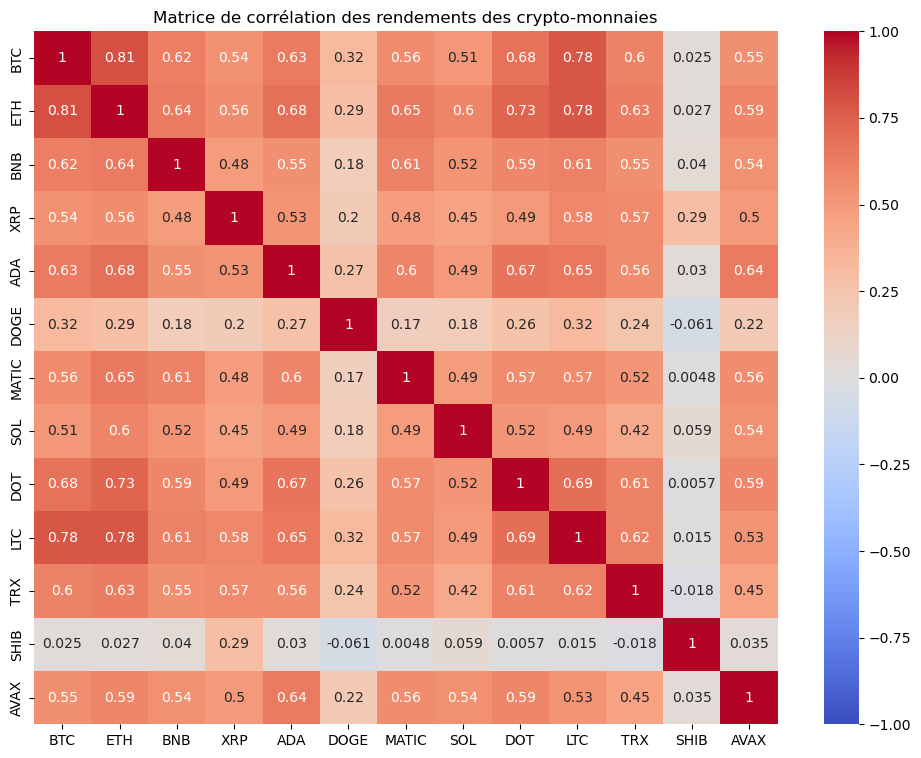

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul des corrélations entre les rendements des crypto-monnaies
correlation_matrix = crypto_returns.corr()

# Affichage de la matrice de corrélation sous forme de heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation des rendements des crypto-monnaies")
plt.show()


In [20]:
import numpy as np

# Supprimer la diagonale (corrélations de 1.0) en la remplacant par NaN
correlation_matrix_no_diag = correlation_matrix.where(~np.eye(correlation_matrix.shape[0], dtype=bool))

# Calculer la moyenne et la médiane des corrélations
stock_correlation_mean = correlation_matrix_no_diag.mean().mean()
stock_correlation_median = correlation_matrix_no_diag.median().median()

print("Moyenne des corrélations :", stock_correlation_mean)
print("Médiane des corrélations :", stock_correlation_median)


Moyenne des corrélations : 0.449981534008968
Médiane des corrélations : 0.5565161854498275


Il est en effet assez courant que les crypto-monnaies soient fortement corrélées positivement entre elles. Plusieurs facteurs peuvent expliquer cette corrélation :

La dépendance au marché global des crypto-monnaies : Les performances de toutes les crypto-monnaies sont en général liées à la performance globale du marché des crypto-monnaies. Si le marché dans son ensemble est en hausse, il est probable que la plupart des cryptos évolueront dans la même direction, et vice versa. Le marché des crypto-monnaies étant encore jeune et en développement, il est souvent influencé par des facteurs macroéconomiques et des nouvelles qui affectent l'ensemble du marché.

Le rôle du Bitcoin (BTC) en tant que référence : Le Bitcoin est souvent considéré comme l'étalon-or du marché des crypto-monnaies. De nombreuses autres cryptos sont évaluées par rapport au Bitcoin, et leur valeur dépend souvent de la performance du Bitcoin. Par conséquent, si le Bitcoin se porte bien, il est probable que d'autres cryptos suivront également cette tendance.

La nature spéculative du marché des crypto-monnaies : Les investisseurs et les traders sur le marché des crypto-monnaies ont souvent une approche spéculative, cherchant à profiter des fluctuations rapides des prix. Cette spéculation peut entraîner des mouvements de marché similaires pour différentes crypto-monnaies.

Les projets et les technologies sous-jacents : De nombreux projets de crypto-monnaie sont basés sur des technologies similaires ou complémentaires, et les développements ou les annonces concernant une technologie particulière peuvent avoir un impact sur les crypto-monnaies associées.

Cependant, il est important de noter que bien que les corrélations soient généralement élevées, elles ne sont pas constantes et peuvent varier au fil du temps. Il peut donc être intéressant d'étudier les corrélations sur différentes périodes pour détecter des variations et des opportunités potentielles de diversification.

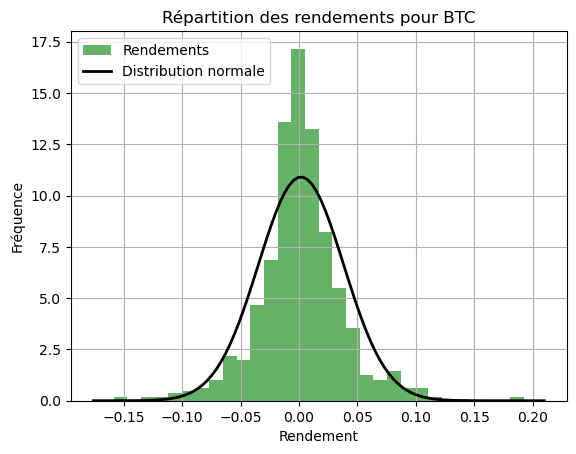

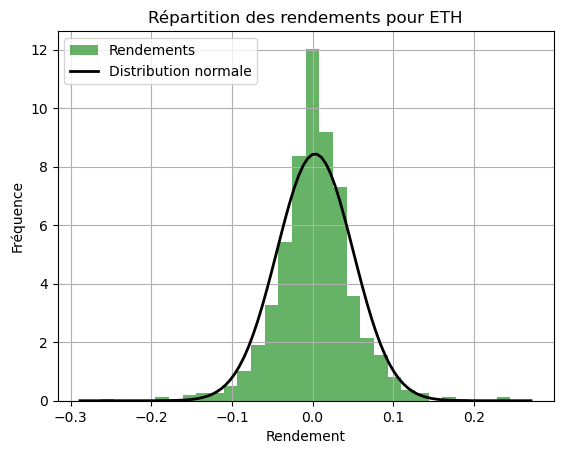

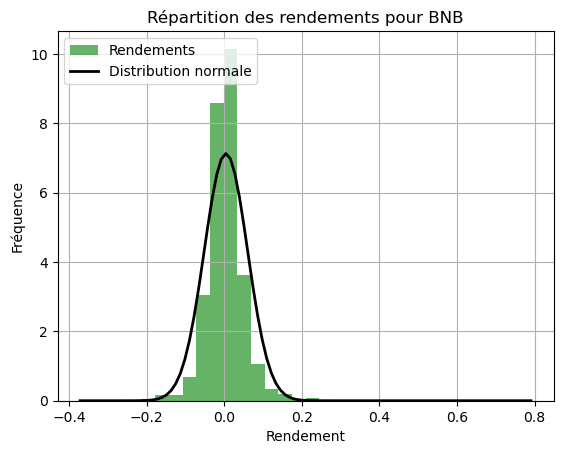

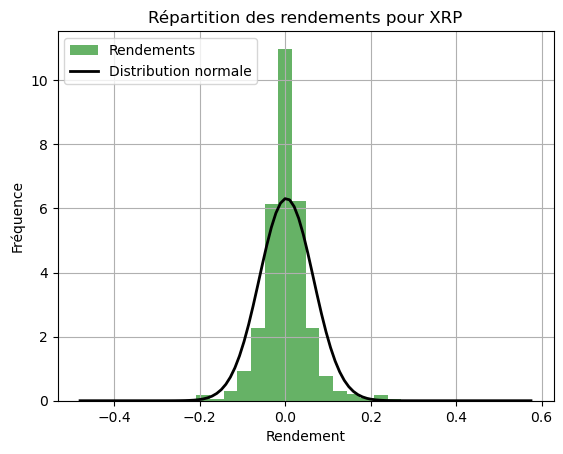

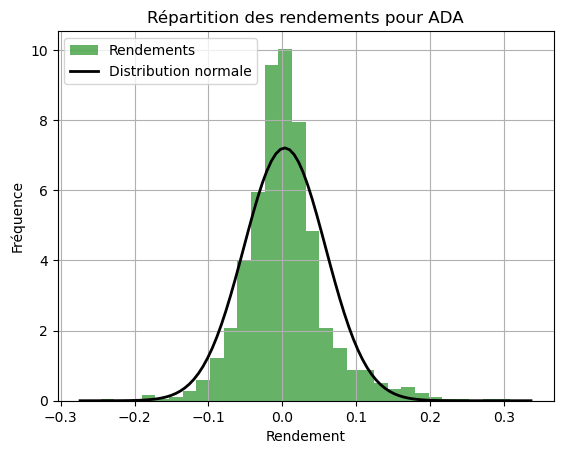

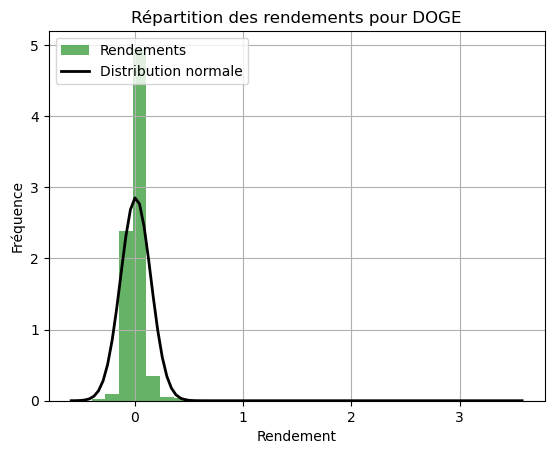

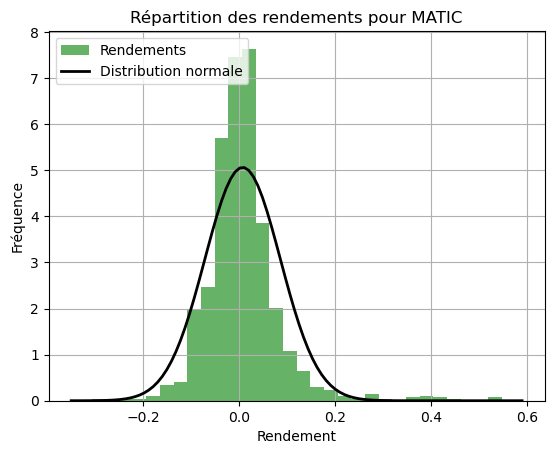

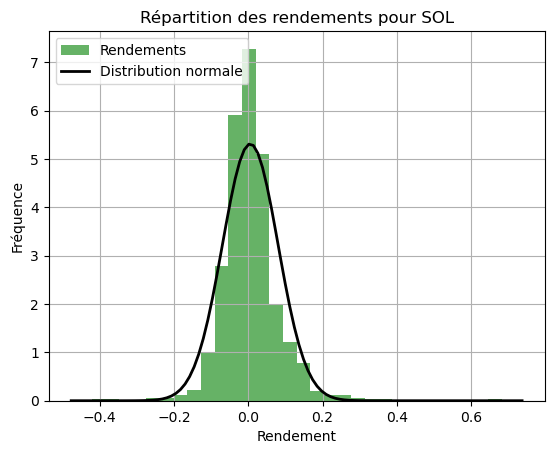

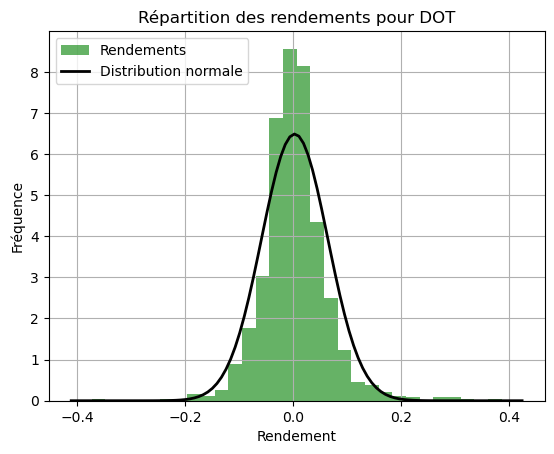

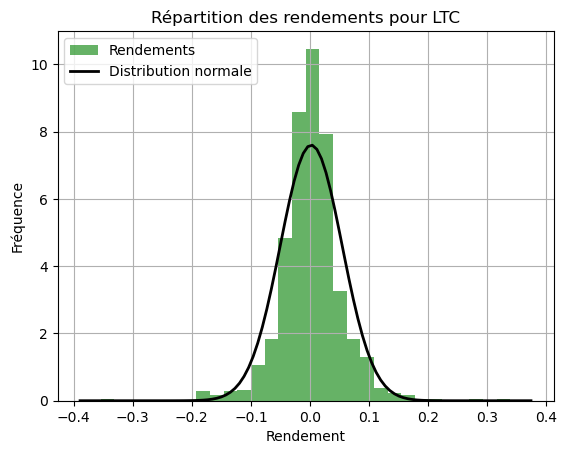

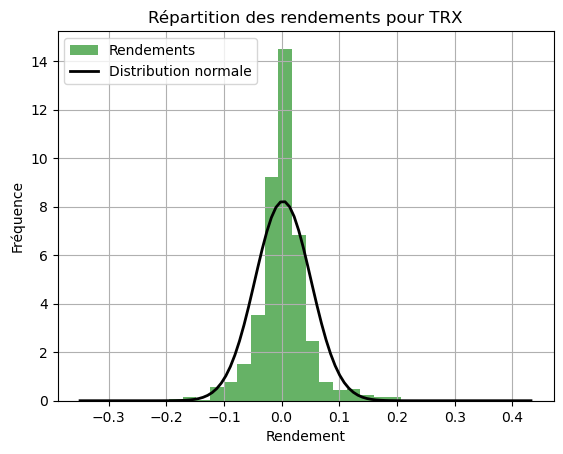

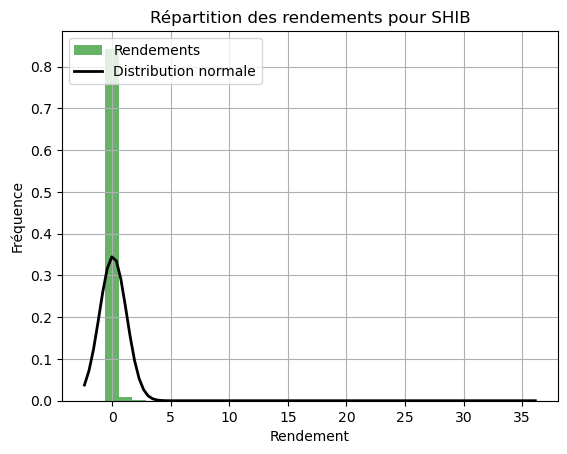

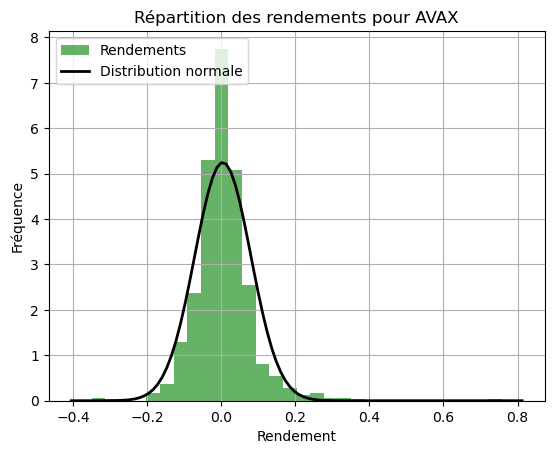

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Calculer les rendements
crypto_returns = crypto_prices.pct_change().dropna()

# Pour chaque colonne (crypto-monnaie) dans les données de rendement
for column in crypto_returns.columns:
    # Obtenir les rendements de la colonne actuelle
    returns = crypto_returns[column]

    # Calculer la moyenne et l'écart-type des rendements
    mean, std = np.mean(returns), np.std(returns)

    # Créer un histogramme des rendements
    plt.hist(returns, bins=30, density=True, alpha=0.6, color='g', label="Rendements")

    # Estimer la densité de probabilité d'une distribution normale
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)
    plt.plot(x, p, 'k', linewidth=2, label="Distribution normale")

    # Configurer le graphique
    plt.title(f"Répartition des rendements pour {column}")
    plt.xlabel("Rendement")
    plt.ylabel("Fréquence")
    plt.legend(loc="upper left")
    plt.grid(True)

    # Afficher le graphique
    plt.show()


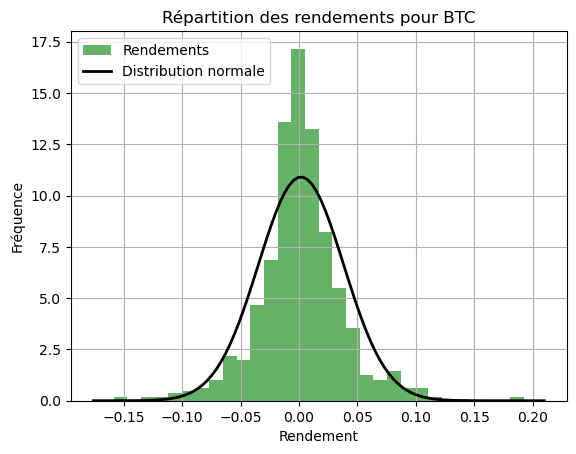

Résultats du test de Jarque-Bera pour BTC:
Statistique: 432.6827
Valeur p: 0.0000
Les rendements de BTC ne semblent pas suivre une distribution normale (On rejette H0).



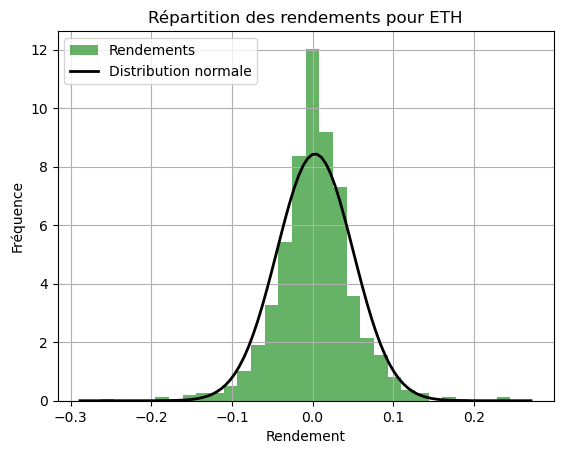

Résultats du test de Jarque-Bera pour ETH:
Statistique: 479.7660
Valeur p: 0.0000
Les rendements de ETH ne semblent pas suivre une distribution normale (On rejette H0).



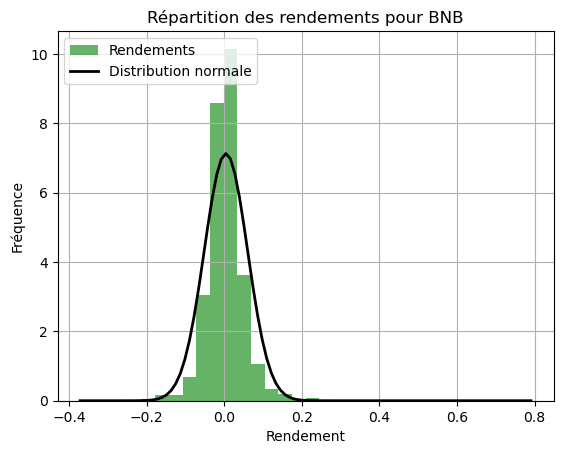

Résultats du test de Jarque-Bera pour BNB:
Statistique: 52394.2439
Valeur p: 0.0000
Les rendements de BNB ne semblent pas suivre une distribution normale (On rejette H0).



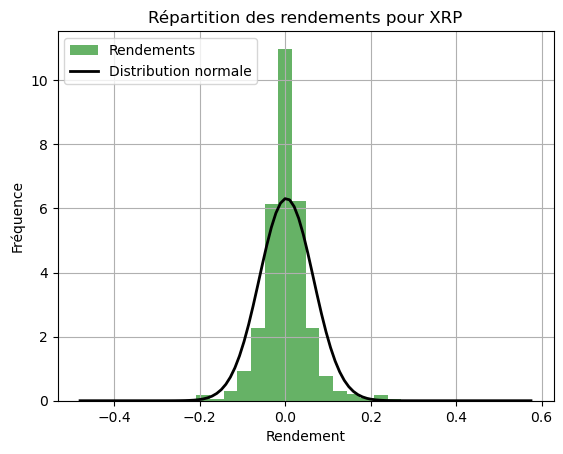

Résultats du test de Jarque-Bera pour XRP:
Statistique: 8307.0773
Valeur p: 0.0000
Les rendements de XRP ne semblent pas suivre une distribution normale (On rejette H0).



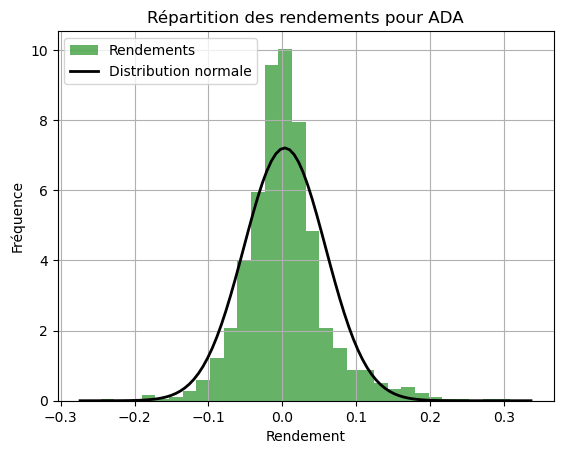

Résultats du test de Jarque-Bera pour ADA:
Statistique: 584.4040
Valeur p: 0.0000
Les rendements de ADA ne semblent pas suivre une distribution normale (On rejette H0).



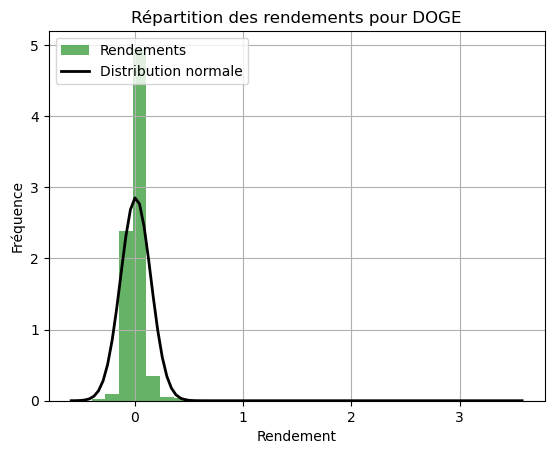

Résultats du test de Jarque-Bera pour DOGE:
Statistique: 5336362.3042
Valeur p: 0.0000
Les rendements de DOGE ne semblent pas suivre une distribution normale (On rejette H0).



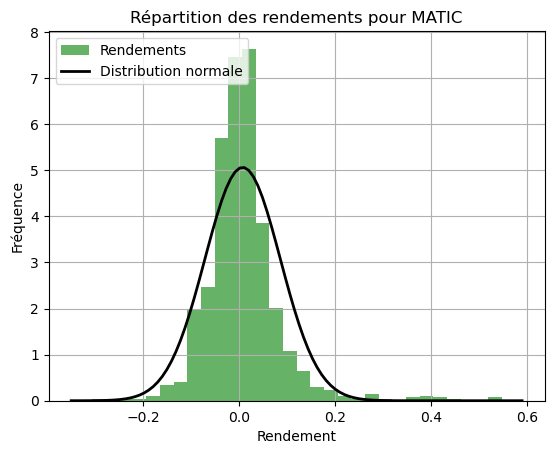

Résultats du test de Jarque-Bera pour MATIC:
Statistique: 4441.5164
Valeur p: 0.0000
Les rendements de MATIC ne semblent pas suivre une distribution normale (On rejette H0).



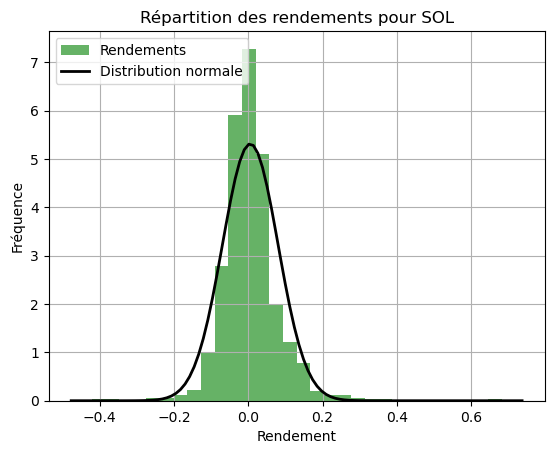

Résultats du test de Jarque-Bera pour SOL:
Statistique: 4103.7083
Valeur p: 0.0000
Les rendements de SOL ne semblent pas suivre une distribution normale (On rejette H0).



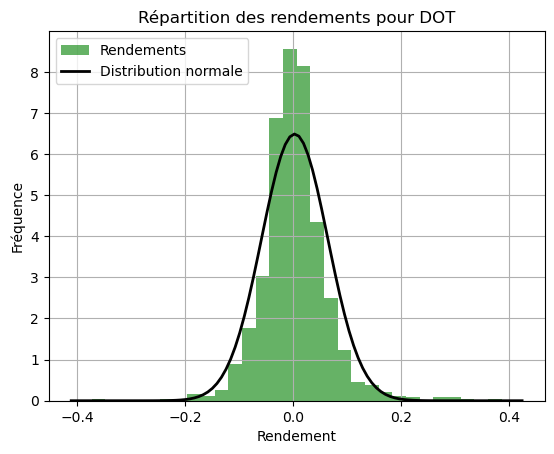

Résultats du test de Jarque-Bera pour DOT:
Statistique: 1520.8265
Valeur p: 0.0000
Les rendements de DOT ne semblent pas suivre une distribution normale (On rejette H0).



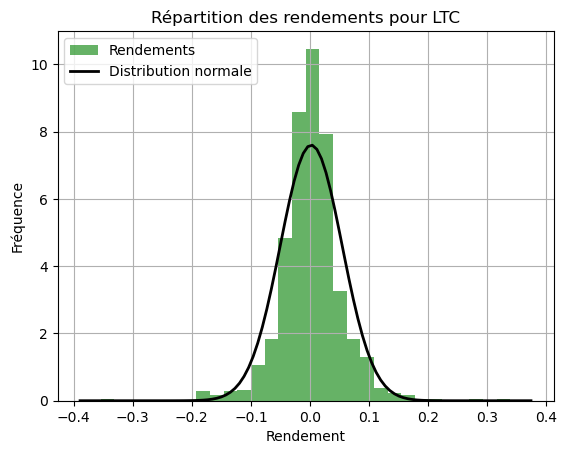

Résultats du test de Jarque-Bera pour LTC:
Statistique: 1293.5771
Valeur p: 0.0000
Les rendements de LTC ne semblent pas suivre une distribution normale (On rejette H0).



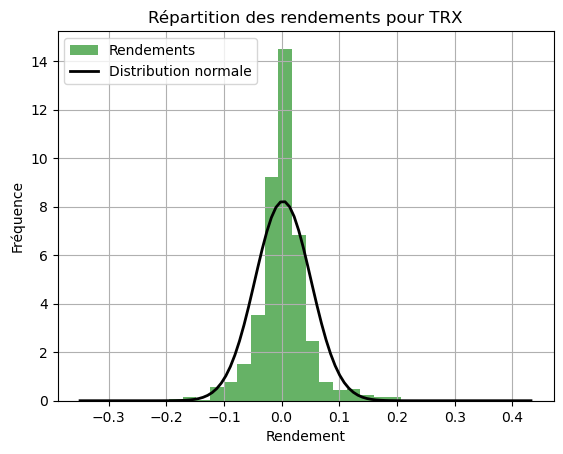

Résultats du test de Jarque-Bera pour TRX:
Statistique: 4108.5650
Valeur p: 0.0000
Les rendements de TRX ne semblent pas suivre une distribution normale (On rejette H0).



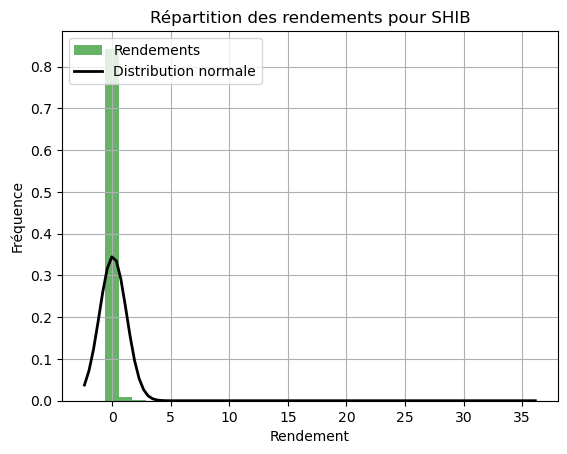

Résultats du test de Jarque-Bera pour SHIB:
Statistique: 27097971.0049
Valeur p: 0.0000
Les rendements de SHIB ne semblent pas suivre une distribution normale (On rejette H0).



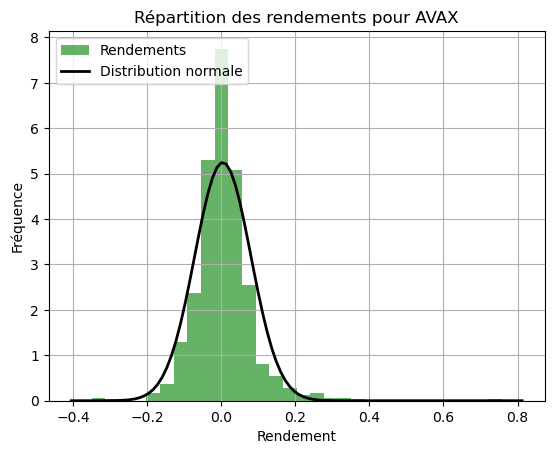

Résultats du test de Jarque-Bera pour AVAX:
Statistique: 7017.0019
Valeur p: 0.0000
Les rendements de AVAX ne semblent pas suivre une distribution normale (On rejette H0).



In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, jarque_bera

# Calculer les rendements
crypto_returns = crypto_prices.pct_change().dropna()

# Pour chaque colonne (crypto-monnaie) dans les données de rendement
for column in crypto_returns.columns:
    # Obtenir les rendements de la colonne actuelle
    returns = crypto_returns[column]

    # Calculer la moyenne et l'écart-type des rendements
    mean, std = np.mean(returns), np.std(returns)

    # Créer un histogramme des rendements
    plt.hist(returns, bins=30, density=True, alpha=0.6, color='g', label="Rendements")

    # Estimer la densité de probabilité d'une distribution normale
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)
    plt.plot(x, p, 'k', linewidth=2, label="Distribution normale")

    # Configurer le graphique
    plt.title(f"Répartition des rendements pour {column}")
    plt.xlabel("Rendement")
    plt.ylabel("Fréquence")
    plt.legend(loc="upper left")
    plt.grid(True)

    # Afficher le graphique
    plt.show()

    # Effectuer le test de Jarque-Bera
    jb_stat, jb_p_value = jarque_bera(returns)
    print(f"Résultats du test de Jarque-Bera pour {column}:")
    print(f"Statistique: {jb_stat:.4f}")
    print(f"Valeur p: {jb_p_value:.4f}")

    # Interpréter les résultats du test
    alpha = 0.05
    if jb_p_value > alpha:
        print(f"Les rendements de {column} semblent suivre une distribution normale (On ne rejette pas H0).\n")
    else:
        print(f"Les rendements de {column} ne semblent pas suivre une distribution normale (On rejette H0).\n")


In [ ]:
crypto_returns.info

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf

def get_stock_data(tickers, start_date, end_date):
    stock_data = yf.download(tickers, start=start_date, end=end_date)
    return stock_data["Adj Close"]

start_date = "2020-01-01"
end_date = "2023-04-29"

# Liste des symboles des 15 premières actions américaines par capitalisation boursière
top_us_stocks = [
    "AAPL", "MSFT", "GOOGL", "GOOG", "AMZN", "BRK-B",
    "TSLA", "JPM", "JNJ", "V", "PG", "NVDA", "MA", "UNH"
]

# Ajout des indices S&P 500 (^GSPC) et Nasdaq 100 (^NDX)
top_us_stocks.extend(["^GSPC", "^NDX"])

stock_prices = get_stock_data(top_us_stocks, start_date, end_date)


In [ ]:
stock_prices.head(15)

In [ ]:

#stock_returns = stock_prices_filled.pct_change().dropna()
stock_returns = stock_prices.pct_change()


# Calculer la matrice de corrélation
stock_correlation_matrix = stock_returns.corr()

# Afficher la matrice de corrélation
print(stock_correlation_matrix)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Afficher la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(stock_correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix for Top US Stocks and Indices")
plt.show()


In [ ]:
import numpy as np

# Supprimer la diagonale (corrélations de 1.0) en la remplacant par NaN
stock_correlation_matrix_no_diag = stock_correlation_matrix.where(~np.eye(stock_correlation_matrix.shape[0], dtype=bool))

# Calculer la moyenne et la médiane des corrélations
stock_correlation_mean = stock_correlation_matrix_no_diag.mean().mean()
stock_correlation_median = stock_correlation_matrix_no_diag.median().median()

print("Moyenne des corrélations :", stock_correlation_mean)
print("Médiane des corrélations :", stock_correlation_median)


In [22]:
import yfinance as yf

def get_stock_data(tickers, start_date, end_date):
    stock_data = yf.download(tickers, start=start_date, end=end_date)
    return stock_data["Adj Close"]

start_date = "2020-01-01"
end_date = "2023-04-29"

# Liste des symboles des 15 premières actions technologiques américaines
top_us_tech_stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "PYPL",
    "ADBE", "CSCO", "INTC", "NFLX", "AVGO", "CRM", "TXN"
]

# Ajout des indices S&P 500 (^GSPC) et Nasdaq 100 (^NDX)
top_us_tech_stocks.extend(["^GSPC", "^NDX"])

stock_prices = get_stock_data(top_us_tech_stocks, start_date, end_date)
stock_returns = stock_prices.pct_change()


# Calculer la matrice de corrélation
stock_correlation_matrix = stock_returns.corr()

# Afficher la matrice de corrélation
print(stock_correlation_matrix)

[*********************100%***********************]  15 of 15 completed
           AAPL      ADBE      AMZN      AVGO       CRM      CSCO     GOOGL  \
AAPL   1.000000  0.712193  0.650083  0.695435  0.601998  0.606144  0.717543   
ADBE   0.712193  1.000000  0.661390  0.678589  0.733640  0.536834  0.720540   
AMZN   0.650083  0.661390  1.000000  0.552749  0.602447  0.417371  0.678391   
AVGO   0.695435  0.678589  0.552749  1.000000  0.584722  0.615600  0.656071   
CRM    0.601998  0.733640  0.602447  0.584722  1.000000  0.464762  0.623066   
CSCO   0.606144  0.536834  0.417371  0.615600  0.464762  1.000000  0.563953   
GOOGL  0.717543  0.720540  0.678391  0.656071  0.623066  0.563953  1.000000   
INTC   0.601553  0.582285  0.460607  0.658912  0.479284  0.585575  0.593004   
MSFT   0.793714  0.796159  0.698995  0.715334  0.690245  0.619079  0.811205   
NFLX   0.485292  0.553718  0.577803  0.450659  0.516020  0.294367  0.486561   
NVDA   0.697931  0.716170  0.643588  0.727822  0.633391  0.5

[*********************100%***********************]  13 of 13 completed


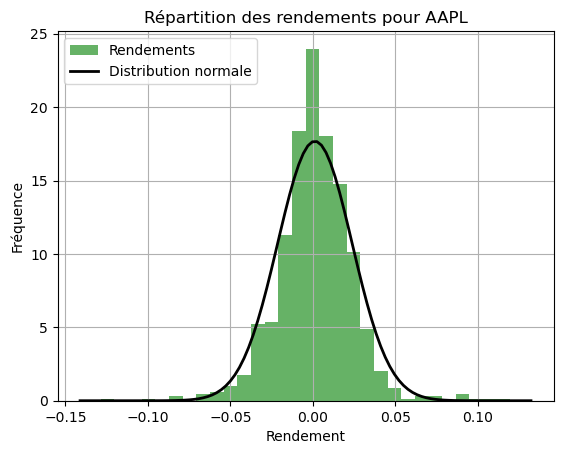

Skewness pour AAPL: 0.0773
Kurtosis pour AAPL: 4.1774
Résultats du test de Jarque-Bera pour AAPL:
Statistique: 608.6965
Valeur p: 0.0000
Les rendements de AAPL ne semblent pas suivre une distribution normale (On rejette H0).



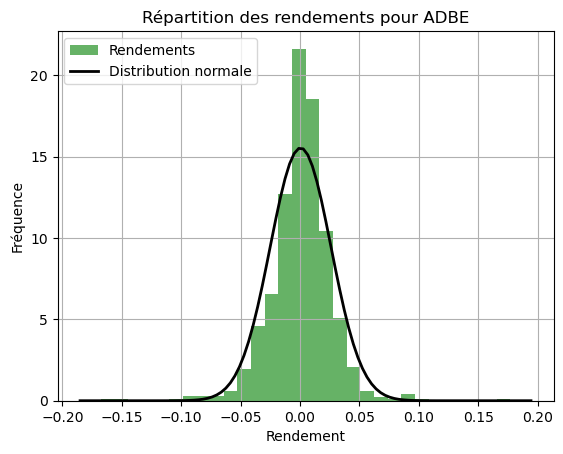

Skewness pour ADBE: -0.3217
Kurtosis pour ADBE: 7.1424
Résultats du test de Jarque-Bera pour ADBE:
Statistique: 1791.4201
Valeur p: 0.0000
Les rendements de ADBE ne semblent pas suivre une distribution normale (On rejette H0).



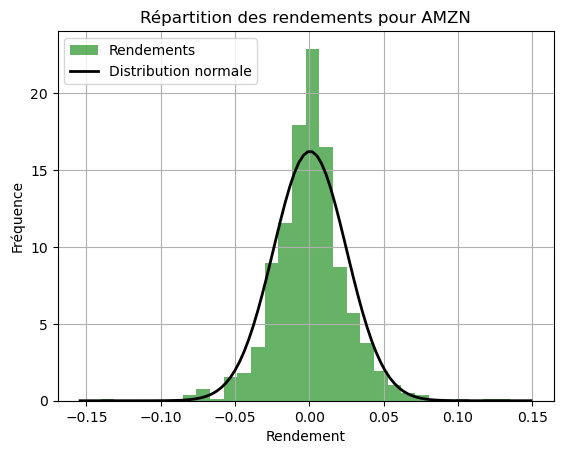

Skewness pour AMZN: 0.0919
Kurtosis pour AMZN: 3.6499
Résultats du test de Jarque-Bera pour AMZN:
Statistique: 465.2090
Valeur p: 0.0000
Les rendements de AMZN ne semblent pas suivre une distribution normale (On rejette H0).



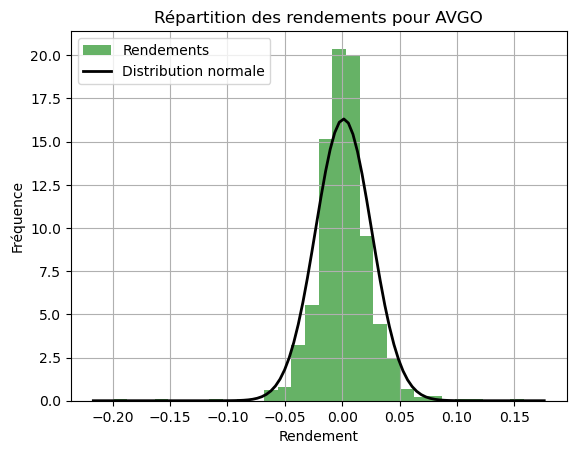

Skewness pour AVGO: -0.5408
Kurtosis pour AVGO: 10.4153
Résultats du test de Jarque-Bera pour AVGO:
Statistique: 3819.4086
Valeur p: 0.0000
Les rendements de AVGO ne semblent pas suivre une distribution normale (On rejette H0).



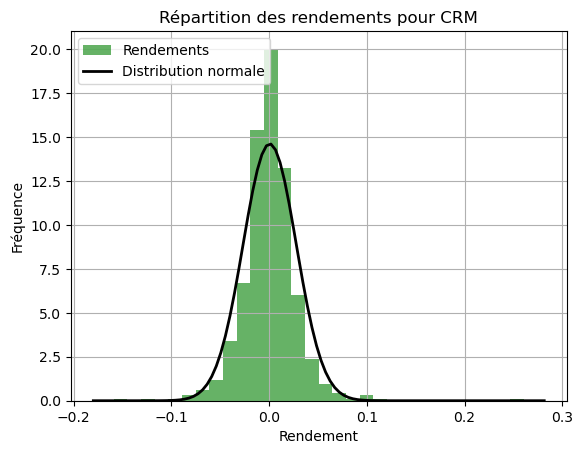

Skewness pour CRM: 0.8114
Kurtosis pour CRM: 12.2024
Résultats du test de Jarque-Bera pour CRM:
Statistique: 5278.3834
Valeur p: 0.0000
Les rendements de CRM ne semblent pas suivre une distribution normale (On rejette H0).



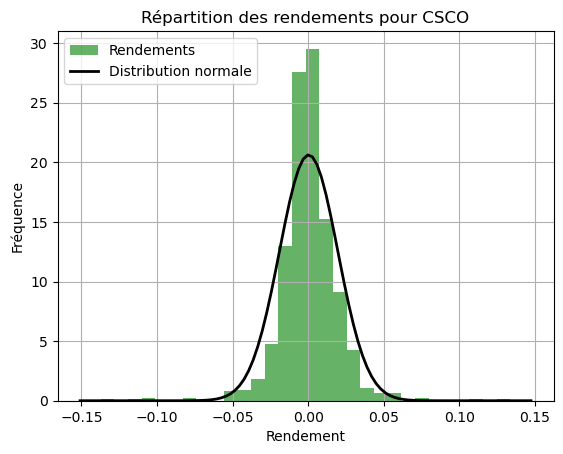

Skewness pour CSCO: -0.3291
Kurtosis pour CSCO: 10.7909
Résultats du test de Jarque-Bera pour CSCO:
Statistique: 4071.1943
Valeur p: 0.0000
Les rendements de CSCO ne semblent pas suivre une distribution normale (On rejette H0).



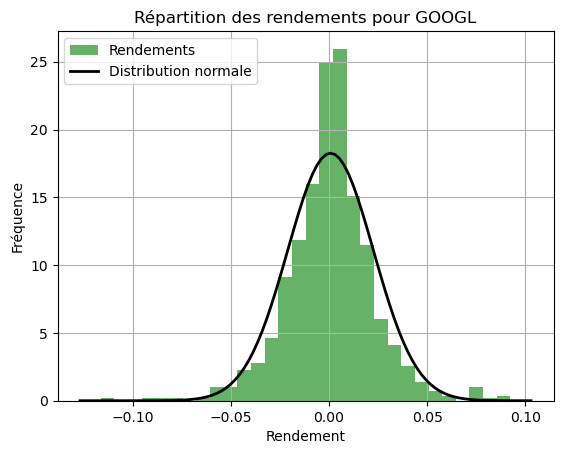

Skewness pour GOOGL: -0.0311
Kurtosis pour GOOGL: 2.8338
Résultats du test de Jarque-Bera pour GOOGL:
Statistique: 279.8568
Valeur p: 0.0000
Les rendements de GOOGL ne semblent pas suivre une distribution normale (On rejette H0).



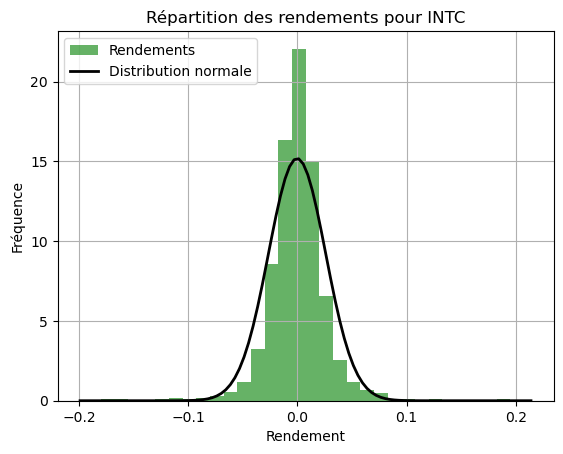

Skewness pour INTC: -0.1990
Kurtosis pour INTC: 9.8775
Résultats du test de Jarque-Bera pour INTC:
Statistique: 3404.0459
Valeur p: 0.0000
Les rendements de INTC ne semblent pas suivre une distribution normale (On rejette H0).



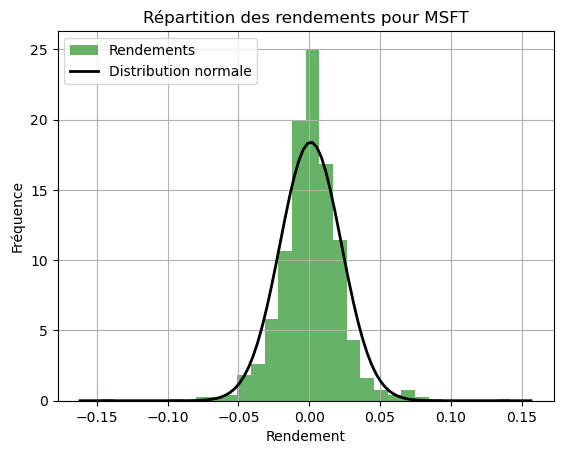

Skewness pour MSFT: 0.0344
Kurtosis pour MSFT: 6.0423
Résultats du test de Jarque-Bera pour MSFT:
Statistique: 1271.8907
Valeur p: 0.0000
Les rendements de MSFT ne semblent pas suivre une distribution normale (On rejette H0).



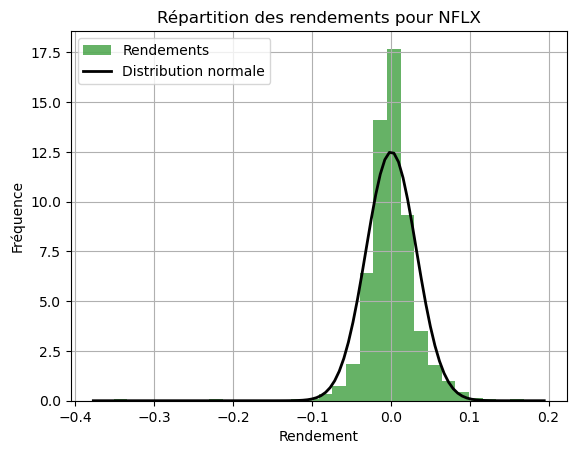

Skewness pour NFLX: -1.5460
Kurtosis pour NFLX: 21.2232
Résultats du test de Jarque-Bera pour NFLX:
Statistique: 16022.8486
Valeur p: 0.0000
Les rendements de NFLX ne semblent pas suivre une distribution normale (On rejette H0).



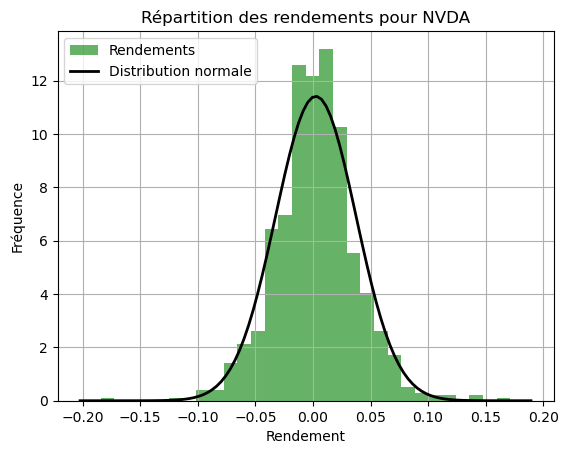

Skewness pour NVDA: 0.0916
Kurtosis pour NVDA: 2.1627
Résultats du test de Jarque-Bera pour NVDA:
Statistique: 164.0897
Valeur p: 0.0000
Les rendements de NVDA ne semblent pas suivre une distribution normale (On rejette H0).



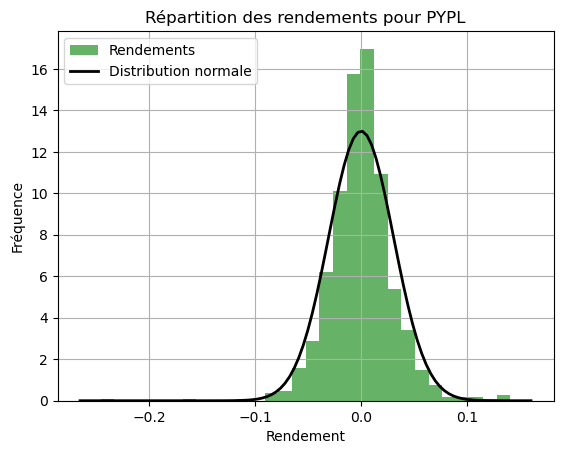

Skewness pour PYPL: -0.2853
Kurtosis pour PYPL: 7.2713
Résultats du test de Jarque-Bera pour PYPL:
Statistique: 1853.0495
Valeur p: 0.0000
Les rendements de PYPL ne semblent pas suivre une distribution normale (On rejette H0).



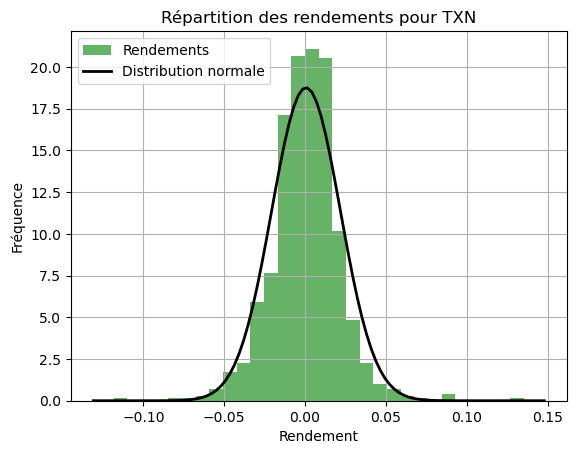

Skewness pour TXN: 0.1487
Kurtosis pour TXN: 4.1699
Résultats du test de Jarque-Bera pour TXN:
Statistique: 608.7792
Valeur p: 0.0000
Les rendements de TXN ne semblent pas suivre une distribution normale (On rejette H0).



In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, jarque_bera, skew, kurtosis
import yfinance as yf

def get_stock_data(tickers, start_date, end_date):
    stock_data = yf.download(tickers, start=start_date, end=end_date)
    return stock_data["Adj Close"]

start_date = "2020-01-01"
end_date = "2023-04-29"

top_us_tech_stocks = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "PYPL",
    "ADBE", "CSCO", "INTC", "NFLX", "AVGO", "CRM", "TXN"
]

stock_prices = get_stock_data(top_us_tech_stocks, start_date, end_date)
stock_returns = stock_prices.pct_change().dropna()

# Pour chaque colonne (action) dans les données de rendement
for column in stock_returns.columns:
    # Obtenir les rendements de la colonne actuelle
    returns = stock_returns[column]

    # Calculer la moyenne et l'écart-type des rendements
    mean, std = np.mean(returns), np.std(returns)

    # Calculer la skewness et le kurtosis
    skewness = skew(returns)
    kurt = kurtosis(returns)

    # Créer un histogramme des rendements
    plt.hist(returns, bins=30, density=True, alpha=0.6, color='g', label="Rendements")

    # Estimer la densité de probabilité d'une distribution normale
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, std)
    plt.plot(x, p, 'k', linewidth=2, label="Distribution normale")

    # Configurer le graphique
    plt.title(f"Répartition des rendements pour {column}")
    plt.xlabel("Rendement")
    plt.ylabel("Fréquence")
    plt.legend(loc="upper left")
    plt.grid(True)

    # Afficher le graphique
    plt.show()

    # Afficher la skewness et le kurtosis
    print(f"Skewness pour {column}: {skewness:.4f}")
    print(f"Kurtosis pour {column}: {kurt:.4f}")

    # Effectuer le test de Jarque-Bera
    jb_stat, jb_p_value = jarque_bera(returns)
    print(f"Résultats du test de Jarque-Bera pour {column}:")
    print(f"Statistique: {jb_stat:.4f}")
    print(f"Valeur p: {jb_p_value:.4f}")

    # Interpréter les résultats du test
    alpha = 0.05
    if jb_p_value > alpha:
        print(f"Les rendements de {column} semblent suivre une distribution normale (On ne rejette pas H0).\n")
    else:
        print(f"Les rendements de {column} ne semblent pas suivre une distribution normale (On rejette H0).\n")


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Afficher la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(stock_correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix for Top US Stocks and Indices")
plt.show()

In [ ]:
import numpy as np

# Supprimer la diagonale (corrélations de 1.0) en la remplacant par NaN
stock_correlation_matrix_no_diag = stock_correlation_matrix.where(~np.eye(stock_correlation_matrix.shape[0], dtype=bool))

# Calculer la moyenne et la médiane des corrélations
stock_correlation_mean = stock_correlation_matrix_no_diag.mean().mean()
stock_correlation_median = stock_correlation_matrix_no_diag.median().median()

print("Moyenne des corrélations :", stock_correlation_mean)
print("Médiane des corrélations :", stock_correlation_median)


In [33]:
# Calculer les rendements moyens
mean_returns = crypto_returns.mean()

# Calculer la matrice de covariance
cov_matrix = crypto_returns.cov()

# Nombre de cryptos
num_cryptos = len(crypto_returns.columns)

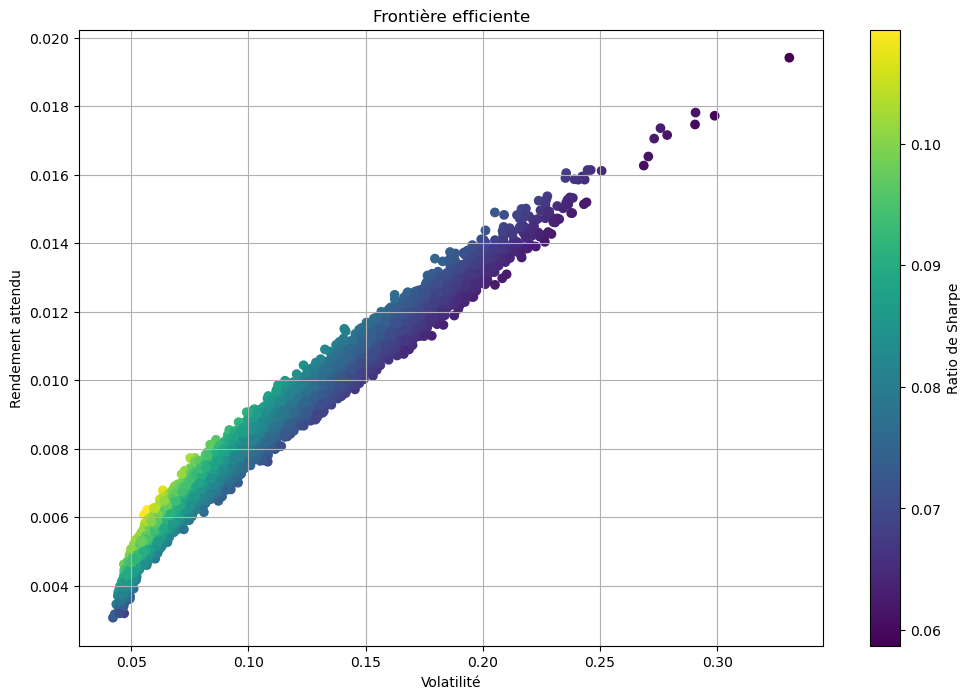

In [34]:
np.random.seed(42)

weights_list = []

# Nombre de portefeuilles à simuler
num_portfolios = 10000

# Initialiser les tableaux pour les résultats
results = np.zeros((num_portfolios, 2 + num_cryptos))

# Générer les portefeuilles aléatoires
for i in range(num_portfolios):
    # Générer des poids aléatoires
    weights = np.random.random(num_cryptos)
    weights /= np.sum(weights)
    weights_list.append(weights)

    # Calculer le rendement attendu
    portfolio_return = np.sum(mean_returns * weights)

    # Calculer la volatilité
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Enregistrer les résultats
    results[i, 0] = portfolio_return
    results[i, 1] = portfolio_std_dev

    # Enregistrer les poids
    for j in range(len(weights)):
        results[i, j + 2] = weights[j]

# Convertir les résultats en DataFrame
results_df = pd.DataFrame(results, columns=["Rendement", "Volatilité"] + list(crypto_returns.columns))

# Tracer la frontière efficiente
plt.figure(figsize=(12, 8))
plt.scatter(results_df["Volatilité"], results_df["Rendement"], c=(results_df["Rendement"] / results_df["Volatilité"]), cmap='viridis')
plt.colorbar(label="Ratio de Sharpe")
plt.xlabel("Volatilité")
plt.ylabel("Rendement attendu")
plt.title("Frontière efficiente")
plt.grid(True)
plt.show()


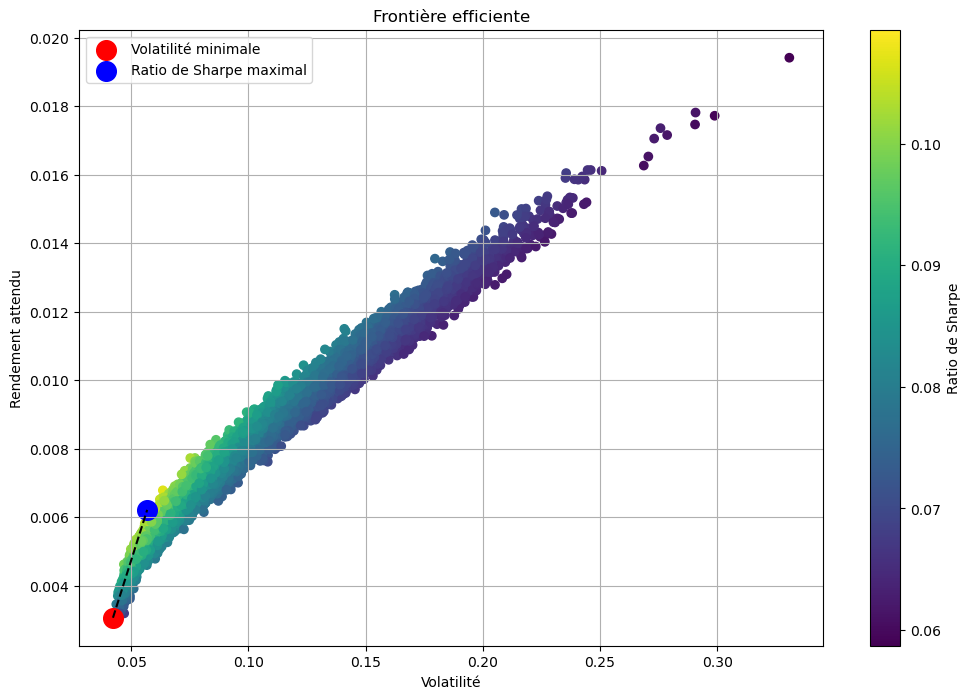

In [30]:
# Trouver le portefeuille à la volatilité minimale
min_volatility_index = results_df["Volatilité"].idxmin()
min_volatility_portfolio = results_df.iloc[min_volatility_index]

# Trouver le portefeuille ayant le ratio de Sharpe maximal
sharpe_ratios = results_df["Rendement"] / results_df["Volatilité"]
max_sharpe_index = sharpe_ratios.idxmax()
max_sharpe_portfolio = results_df.iloc[max_sharpe_index]

# Tracer la frontière efficiente
plt.figure(figsize=(12, 8))
plt.scatter(results_df["Volatilité"], results_df["Rendement"], c=(results_df["Rendement"] / results_df["Volatilité"]), cmap='viridis')
plt.colorbar(label="Ratio de Sharpe")
plt.xlabel("Volatilité")
plt.ylabel("Rendement attendu")
plt.title("Frontière efficiente")

# Marquer le portefeuille à la volatilité minimale et le portefeuille ayant le ratio de Sharpe maximal
plt.scatter(min_volatility_portfolio["Volatilité"], min_volatility_portfolio["Rendement"], c='red', marker='o', s=200, label="Volatilité minimale")
plt.scatter(max_sharpe_portfolio["Volatilité"], max_sharpe_portfolio["Rendement"], c='blue', marker='o', s=200, label="Ratio de Sharpe maximal")

# Tracer la ligne reliant les deux points
plt.plot([min_volatility_portfolio["Volatilité"], max_sharpe_portfolio["Volatilité"]], [min_volatility_portfolio["Rendement"], max_sharpe_portfolio["Rendement"]], linestyle='--', color='black')

plt.legend(loc="upper left")
plt.grid(True)
plt.show()


In [35]:
# Trouver le portefeuille avec le meilleur ratio de Sharpe
best_sharpe_ratio_index = (results_df["Rendement"] / results_df["Volatilité"]).idxmax()
best_sharpe_ratio_portfolio = results_df.iloc[best_sharpe_ratio_index]

# Récupérer les poids du portefeuille avec le meilleur ratio de Sharpe
best_sharpe_weights = weights_list[best_sharpe_ratio_index]

# Créer un DataFrame avec la composition du portefeuille optimal
optimal_portfolio = pd.DataFrame(data=best_sharpe_weights, index=crypto_returns.columns, columns=["Poids"])
optimal_portfolio["Poids"] = optimal_portfolio["Poids"].apply(lambda x: round(x * 100, 2))  # Convertir les poids en pourcentages

print("Composition du portefeuille optimal :")
print(optimal_portfolio)

Composition du portefeuille optimal :
       Poids
BTC     2.31
ETH    10.29
BNB    16.47
XRP     1.84
ADA     9.06
DOGE   15.88
MATIC  16.52
SOL     9.44
DOT     0.46
LTC     1.94
TRX    10.77
SHIB    2.27
AVAX    2.74


In [36]:
# Trouver le portefeuille avec le meilleur ratio de Sharpe
best_sharpe_ratio_index = (results_df["Rendement"] / results_df["Volatilité"]).idxmax()
best_sharpe_ratio_portfolio = results_df.iloc[best_sharpe_ratio_index]

# Récupérer les poids du portefeuille avec le meilleur ratio de Sharpe
best_sharpe_weights = weights_list[best_sharpe_ratio_index]

# Créer un DataFrame avec la composition du portefeuille optimal
optimal_portfolio = pd.DataFrame(data=best_sharpe_weights, index=crypto_returns.columns, columns=["Poids"])
optimal_portfolio["Poids"] = optimal_portfolio["Poids"].apply(lambda x: round(x * 100, 2))  # Convertir les poids en pourcentages

print("Composition du portefeuille optimal :")
print(optimal_portfolio)

Composition du portefeuille optimal :
       Poids
BTC     2.31
ETH    10.29
BNB    16.47
XRP     1.84
ADA     9.06
DOGE   15.88
MATIC  16.52
SOL     9.44
DOT     0.46
LTC     1.94
TRX    10.77
SHIB    2.27
AVAX    2.74


In [40]:
best_sharpe_ratio_portfolio

Rendement     0.006215
Volatilité    0.056819
BTC           0.023136
ETH           0.102936
BNB           0.164729
XRP           0.018372
ADA           0.090630
DOGE          0.158780
MATIC         0.165244
SOL           0.094390
DOT           0.004579
LTC           0.019386
TRX           0.107669
SHIB          0.022730
AVAX          0.027420
Name: 2590, dtype: float64

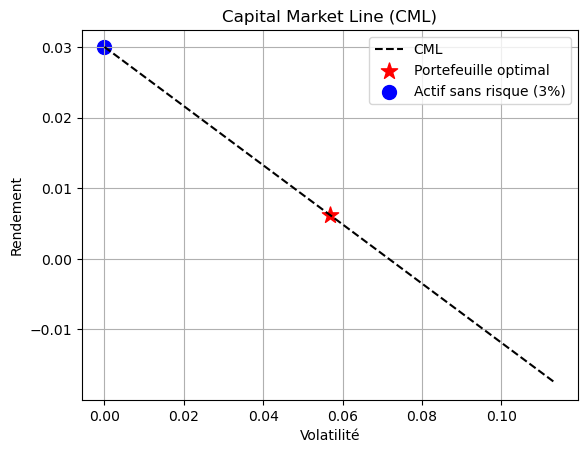

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Rendement sans risque (en décimal)
risk_free_rate = 0.03

# Rendement et volatilité du portefeuille optimal
optimal_portfolio_return = best_sharpe_ratio_portfolio["Rendement"]
optimal_portfolio_volatility = best_sharpe_ratio_portfolio["Volatilité"]

# Créer une gamme de volatilités pour la CML
volatilities = np.linspace(0, optimal_portfolio_volatility * 2, 100)

# Calculer les rendements correspondants pour la CML
cml_returns = risk_free_rate + (optimal_portfolio_return - risk_free_rate) / optimal_portfolio_volatility * volatilities

# Tracer la CML
plt.plot(volatilities, cml_returns, linestyle="--", color="black", label="CML")

# Ajouter le point correspondant au portefeuille optimal
plt.scatter(optimal_portfolio_volatility, optimal_portfolio_return, marker="*", color="red", s=150, label="Portefeuille optimal")

# Ajouter le point correspondant à l'actif sans risque
plt.scatter(0, risk_free_rate, marker="o", color="blue", s=100, label="Actif sans risque (3%)")

# Configurer le graphique
plt.xlabel("Volatilité")
plt.ylabel("Rendement")
plt.title("Capital Market Line (CML)")
plt.legend()
plt.grid()
plt.show()
